In [1]:
"""Hero-Chart 2 (H2): Schere zwischen eigenen Bundes-Investitionen und Transfers.

Zentrale Aussage: Eigene Investitionen stagnieren, Transfer-Investitionen
verdoppeln ihren Anteil. Der Bund verteilt zunehmend, baut nicht selbst.

Output: figures/h2_schere.png + .pdf
"""
import sys
from pathlib import Path
sys.path.insert(0, '..')  # repo root, relativ zum notebooks/-Verzeichnis

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from src import FIGURES_DIR
from src.load import load
from src.style import apply_style, COLORS, add_quelle

In [3]:
apply_style()
df = load()  # nutzt Repo-Root-Default aus src.load

In [4]:
# Daten
d = df[(df['any_tag'] == 1) & (df['digi_soll_eng'] > 0)].copy()
agg = (d[d['typ_invest'].notna()]
       .groupby(['jahr', 'typ_invest'])['digi_soll_eng']
       .sum().div(1e6).unstack().fillna(0))
total = d.groupby('jahr')['digi_soll_eng'].sum().div(1e6)

In [5]:
jahre = sorted(agg.index)
eigene = agg.loc[jahre, 'A_eigene_Invest'].values
transfer = agg.loc[jahre, 'B_Transfer_Invest'].values
eigene_pct = (eigene / total.loc[jahre].values * 100)
transfer_pct = (transfer / total.loc[jahre].values * 100)

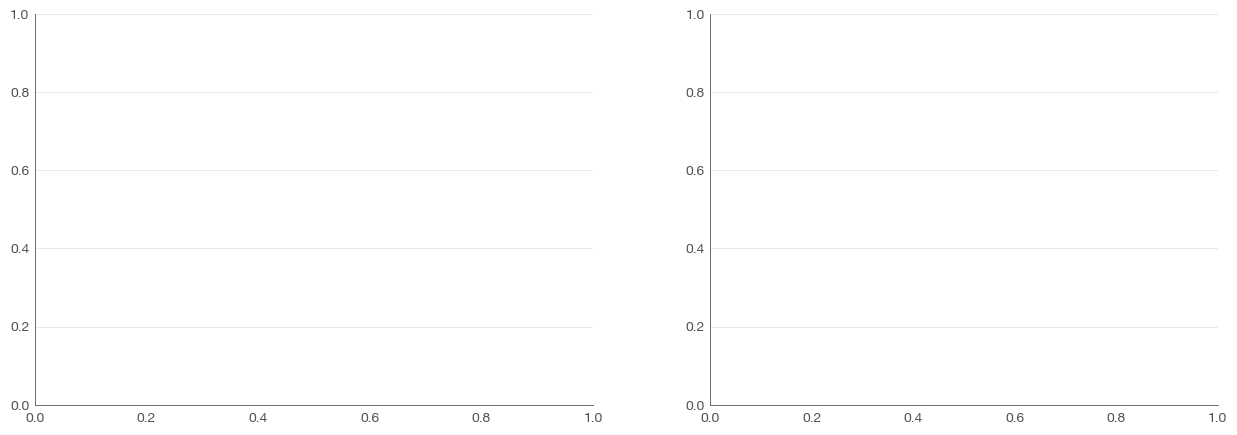

In [6]:
# Plot: zwei Subplots nebeneinander - links absolute Mrd, rechts Anteile
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6.3), gridspec_kw={'width_ratios': [1.1, 1]})
fig.subplots_adjust(left=0.06, right=0.97, top=0.78, bottom=0.16, wspace=0.22)

In [7]:
# ---- LINKS: Absolutwerte in Mrd. EUR ----
ax1.plot(jahre, transfer, color=COLORS['akzent'], linewidth=3,
         marker='o', markersize=8, label='Transfer-Investitionen', zorder=3)
ax1.plot(jahre, eigene, color=COLORS['neutral'], linewidth=2.2,
         linestyle='--', marker='s', markersize=7, label='Eigene Bundes-Investitionen', zorder=2)

In [8]:
# Fuelle die Schere zwischen den Linien
ax1.fill_between(jahre, eigene, transfer, color=COLORS['akzent'], alpha=0.07, zorder=1)

In [9]:
# Endpunkt-Beschriftungen
ax1.text(jahre[-1] + 0.08, transfer[-1], f' {transfer[-1]:.2f} Mrd',
         va='center', fontsize=11, color=COLORS['akzent'], weight='medium')
ax1.text(jahre[-1] + 0.08, eigene[-1], f' {eigene[-1]:.2f} Mrd',
         va='center', fontsize=11, color=COLORS['text_secondary'])

Text(2024.08, 1.0844528, ' 1.08 Mrd')

In [10]:
# Startpunkt-Beschriftungen
ax1.text(jahre[0] - 0.1, transfer[0], f'{transfer[0]:.2f} ',
         va='center', ha='right', fontsize=10, color=COLORS['akzent'])
ax1.text(jahre[0] - 0.1, eigene[0], f'{eigene[0]:.2f} ',
         va='center', ha='right', fontsize=10, color=COLORS['text_secondary'])

Text(2018.9, 0.9270306374999999, '0.93 ')

In [11]:
# Linien-Labels direkt am Chart, oben
ax1.text(2022, 4.6, 'Investitions-Zuschüsse an\nLänder und Private',
         fontsize=10, color=COLORS['akzent'], weight='medium', ha='center')
ax1.text(2022.2, 1.65, 'Eigene Investitionen des Bundes',
         fontsize=10, color=COLORS['text_secondary'], ha='center')

Text(2022.2, 1.65, 'Eigene Investitionen des Bundes')

In [12]:
ax1.set_xticks(jahre)
ax1.set_xticklabels([str(j) for j in jahre])
ax1.set_xlim(2018.4, 2024.7)
ax1.set_ylim(0, 6.5)
ax1.set_ylabel('Mrd € (digi_soll_eng)')
ax1.set_title('Absolute Volumina', loc='left', fontsize=11,
              color=COLORS['text_secondary'], pad=10)

Text(0.0, 1.0, 'Absolute Volumina')

In [13]:
# ---- RECHTS: Anteile am Digital-Soll ----
ax2.plot(jahre, transfer_pct, color=COLORS['akzent'], linewidth=3,
         marker='o', markersize=8, zorder=3)
ax2.plot(jahre, eigene_pct, color=COLORS['neutral'], linewidth=2.2,
         linestyle='--', marker='s', markersize=7, zorder=2)
ax2.fill_between(jahre, eigene_pct, transfer_pct, color=COLORS['akzent'],
                 alpha=0.07, zorder=1)

In [14]:
ax2.text(jahre[-1] + 0.08, transfer_pct[-1], f' {transfer_pct[-1]:.1f} %',
         va='center', fontsize=11, color=COLORS['akzent'], weight='medium')
ax2.text(jahre[-1] + 0.08, eigene_pct[-1], f' {eigene_pct[-1]:.1f} %',
         va='center', fontsize=11, color=COLORS['text_secondary'])
ax2.text(jahre[0] - 0.1, transfer_pct[0], f'{transfer_pct[0]:.1f} % ',
         va='center', ha='right', fontsize=10, color=COLORS['akzent'])
ax2.text(jahre[0] - 0.1, eigene_pct[0], f'{eigene_pct[0]:.1f} % ',
         va='center', ha='right', fontsize=10, color=COLORS['text_secondary'])

Text(2018.9, 10.895789027417752, '10.9 % ')

In [15]:
ax2.set_xticks(jahre)
ax2.set_xticklabels([str(j) for j in jahre])
ax2.set_xlim(2018.4, 2024.7)
ax2.set_ylim(0, 36)
ax2.set_ylabel('Anteil am Digital-Soll')
ax2.set_title('Anteil am gesamten Digital-Soll', loc='left', fontsize=11,
              color=COLORS['text_secondary'], pad=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f} %'))

In [16]:
# Titel und Kernaussage ueber beiden
fig.text(0.06, 0.93,
         'Der Bund verteilt mehr, baut aber nicht selbst auf',
         fontsize=15, weight='medium', color=COLORS['text'])
fig.text(0.06, 0.89,
         'Eigene Bundes-Investitionen in Digitalisierung gegen Investitions-Zuschüsse an Dritte, 2019–2024',
         fontsize=10, color=COLORS['text_secondary'])

Text(0.06, 0.89, 'Eigene Bundes-Investitionen in Digitalisierung gegen Investitions-Zuschüsse an Dritte, 2019–2024')

In [17]:
# Annotation: Faktor
fig.text(0.06, 0.045,
         f'2019–2024: Eigene Investitionen +{(eigene[-1]/eigene[0]-1)*100:.0f}%, '
         f'Transfer-Investitionen +{(transfer[-1]/transfer[0]-1)*100:.0f}%.',
         fontsize=9, color=COLORS['text_tertiary'], style='italic')
fig.text(0.06, 0.02,
         'Quelle: Digitalhaushalt Open Data (ZEW/Agora), enge Abgrenzung. '
         'Investitionen: Hauptgruppe 8, eigene = UG 81/82, Transfer = UG 83/86/87/88/89.',
         fontsize=8, color=COLORS['text_tertiary'], style='italic')

Text(0.06, 0.02, 'Quelle: Digitalhaushalt Open Data (ZEW/Agora), enge Abgrenzung. Investitionen: Hauptgruppe 8, eigene = UG 81/82, Transfer = UG 83/86/87/88/89.')

In [18]:
# Speichern
out_dir = FIGURES_DIR
fig.savefig(out_dir / 'h2_schere.png', dpi=200)
fig.savefig(out_dir / 'h2_schere.pdf')
print(f"Gespeichert: {out_dir/'h2_schere.png'}")
print(f"Gespeichert: {out_dir/'h2_schere.pdf'}")

Gespeichert: /Users/moe/Documents/GitHub/agora_challenge/figures/h2_schere.png
Gespeichert: /Users/moe/Documents/GitHub/agora_challenge/figures/h2_schere.pdf
